# **Libraries**

In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt

def mape(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
data = pd.read_csv('tab_training.csv')
data_validation = pd.read_csv('tab_validation.csv')

data.head(), data_validation.head()

(   Unnamed: 0    lon   lat  year  month    prec       temp         etp
 0           1 -61.25 -2.75  1981      1  274.22  25.152581  114.149562
 1           2 -61.25 -2.75  1981      2  312.38  25.031071  104.416602
 2           3 -61.25 -2.75  1981      3  149.40  26.163548  134.323249
 3           4 -61.25 -2.75  1981      4  218.41  25.731333  121.808682
 4           5 -61.25 -2.75  1981      5  176.00  25.560000  122.211982,
    Unnamed: 0    lon   lat  year  month    prec       temp         etp
 0           1 -61.25 -2.75  2015      1  211.06  25.676774  113.772924
 1           2 -61.25 -2.75  2015      2  132.62  26.078929  113.266134
 2           3 -61.25 -2.75  2015      3  215.90  25.838065  119.822282
 3           4 -61.25 -2.75  2015      4  128.65  25.991000  118.194390
 4           5 -61.25 -2.75  2015      5  123.99  25.998065  121.540763)

# **Pre processing**

In [3]:
x1 = data[['lon','lat','year','month']]
x2 = data[['prec','temp']]
y = data['etp']

x1_vali= data_validation[['lon','lat','year','month']]
x2_validation = data_validation[['prec','temp']]
y_validation = data_validation['etp']

In [4]:
x2 = StandardScaler().fit_transform(x2)
x2 = pd.DataFrame(x2, columns=[data.columns[5:7]])
x2.head()

x2_validation = StandardScaler().fit_transform(x2_validation)
x2_validation = pd.DataFrame(x2_validation, columns=[data_validation.columns[5:7]])
x2_validation.head(),x2_validation.head()

(       prec      temp
 0  0.563163 -0.756012
 1 -0.366846 -0.474550
 2  0.620548 -0.643127
 3 -0.413916 -0.536090
 4 -0.469166 -0.531145,
        prec      temp
 0  0.563163 -0.756012
 1 -0.366846 -0.474550
 2  0.620548 -0.643127
 3 -0.413916 -0.536090
 4 -0.469166 -0.531145)

In [5]:
x = pd.concat([x1,x2],axis=1, join='inner')
x_validation = pd.concat([x1_vali,x2_validation],axis=1, join='inner')

x.head(),x_validation.head()

(     lon   lat  year  month   (prec,)   (temp,)
 0 -61.25 -2.75  1981      1  0.800123 -0.886660
 1 -61.25 -2.75  1981      2  1.182811 -1.004685
 2 -61.25 -2.75  1981      3 -0.451633  0.095320
 3 -61.25 -2.75  1981      4  0.240433 -0.324502
 4 -61.25 -2.75  1981      5 -0.184875 -0.490923,
      lon   lat  year  month   (prec,)   (temp,)
 0 -61.25 -2.75  2015      1  0.563163 -0.756012
 1 -61.25 -2.75  2015      2 -0.366846 -0.474550
 2 -61.25 -2.75  2015      3  0.620548 -0.643127
 3 -61.25 -2.75  2015      4 -0.413916 -0.536090
 4 -61.25 -2.75  2015      5 -0.469166 -0.531145)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=1)
x_train.to_csv('x_train.csv')
y_test.to_csv('y_test.csv')
y_train.to_csv('y_train.csv')
x_test.to_csv('x_test.csv')

# **Random Forest**

In [7]:
rf_model = rfs().fit(x_train, y_train)
             

## **Random Search param**

In [8]:
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 1000, num = 50)]
# Number of features to consider at every split
max_features = [1,2,3]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 5)]

hyperpar_space = {'max_depth':max_depth,
                  'n_estimators':n_estimators,
                  'max_features':max_features
                 }

rs_rf = RandomizedSearchCV(rf_model, param_distributions=hyperpar_space,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train, y_train)

In [9]:
#hyperpar_space

In [10]:
pd.DataFrame.from_dict(rs_rf.cv_results_).to_csv('random_Forest_iter.csv')
pd.DataFrame.from_dict(rs_rf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,11.881087,0.751416,0.543392,0.180783,534,1,100,"{'n_estimators': 534, 'max_features': 1, 'max_...",0.986482,0.984687,...,0.997793,0.997853,0.997757,0.997919,0.997861,0.997875,0.997825,0.997737,0.997835,0.000057
1,8.392740,0.051477,0.283146,0.025530,398,1,50,"{'n_estimators': 398, 'max_features': 1, 'max_...",0.986447,0.985314,...,0.997756,0.997778,0.997775,0.997606,0.997795,0.997854,0.997859,0.997874,0.997787,0.000078
2,18.227285,0.651788,0.724041,0.236178,806,1,50,"{'n_estimators': 806, 'max_features': 1, 'max_...",0.987104,0.985013,...,0.997882,0.997850,0.997864,0.997837,0.997872,0.997854,0.997897,0.997829,0.997876,0.000050
3,37.771684,1.067892,2.155141,1.525239,980,3,75,"{'n_estimators': 980, 'max_features': 3, 'max_...",0.998876,0.998940,...,0.999829,0.999823,0.999824,0.999830,0.999824,0.999827,0.999810,0.999798,0.999822,0.000010
4,3.888102,0.093559,0.167891,0.011708,825,2,1,"{'n_estimators': 825, 'max_features': 2, 'max_...",0.514548,0.469782,...,0.475951,0.471055,0.475087,0.466284,0.473745,0.483731,0.475139,0.467119,0.474134,0.005833
5,10.561745,0.208507,0.280818,0.023804,360,2,100,"{'n_estimators': 360, 'max_features': 2, 'max_...",0.997875,0.997933,...,0.999645,0.999658,0.999641,0.999659,0.999660,0.999651,0.999639,0.999622,0.999649,0.000012
6,10.814898,0.318487,0.195359,0.010117,282,3,25,"{'n_estimators': 282, 'max_features': 3, 'max_...",0.998805,0.998930,...,0.999809,0.999813,0.999804,0.999827,0.999816,0.999821,0.999809,0.999780,0.999812,0.000013
7,3.230021,0.034038,0.140048,0.004796,709,2,1,"{'n_estimators': 709, 'max_features': 2, 'max_...",0.507659,0.468896,...,0.472625,0.478126,0.475803,0.474097,0.471333,0.467010,0.464471,0.454407,0.470488,0.006923
8,27.613227,0.633860,0.526684,0.042611,728,3,75,"{'n_estimators': 728, 'max_features': 3, 'max_...",0.998865,0.998977,...,0.999830,0.999818,0.999814,0.999828,0.999829,0.999828,0.999808,0.999806,0.999821,0.000008
9,3.291368,0.040871,0.145778,0.004202,728,2,1,"{'n_estimators': 728, 'max_features': 2, 'max_...",0.511984,0.484018,...,0.462300,0.471286,0.483726,0.487297,0.478686,0.474399,0.470757,0.479097,0.477125,0.007082


<AxesSubplot:>

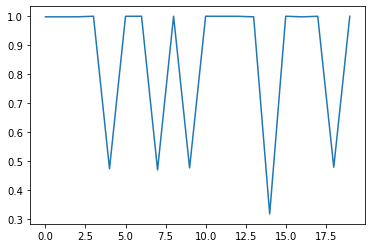

In [11]:
pd.DataFrame.from_dict(rs_rf.cv_results_)['mean_train_score'].plot()

In [12]:
print("Optimal hyperparameter combination:", rs_rf.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_rf.best_score_)
print()

Optimal hyperparameter combination: {'n_estimators': 728, 'max_features': 3, 'max_depth': 75}

Mean cross-validated training accuracy score: 0.9986243774154746



### ***Feature Importance***

In [13]:
importance = rs_rf.best_estimator_.feature_importances_
importance_graf = pd.DataFrame({'lon':[importance[0]],'lat':[importance[1]],
                                     'year':[importance[2]],'month':[importance[3]],
                                     'prec':[importance[4]], 'temp':[importance[5]]
                                })
importance_graf

,lon,lat,year,month,prec,temp
0,0.005145,0.004956,0.020883,0.131461,0.091162,0.746393


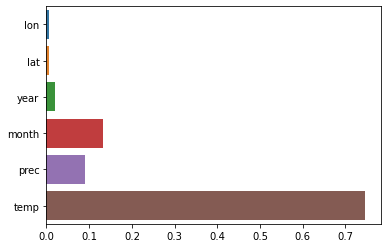

In [14]:
sns.barplot(data=importance_graf, orient='h');

## **Train**

In [15]:
yest_train = rs_rf.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('random_Forest_train_est.csv')

In [16]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
14083,132.035181,131.986140
13017,142.787187,142.675035
11578,121.857273,121.923832
3292,133.351498,133.249855
13968,106.459225,106.392974


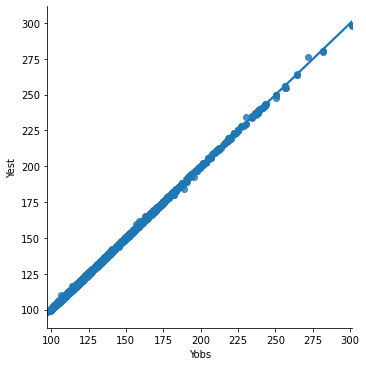

In [17]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [18]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
rf_mape = mape(y_train,yest_train)

r2,rmse,rrmse,rf_mape

(0.9998676170768229,
 0.23298732808631303,
 0.17959524637840366,
 0.09157088095879065)

findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Segoe UI Bold'] not found. Falling back to DejaVu Sans.


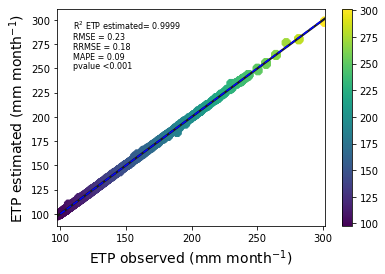

In [19]:
x=[100,300]
y=x

points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis") 
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

plt.plot(x,y, 'b--',data=None)

pvalue = 0.001
plt.text(110, 290, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(110,280, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,270, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,260, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(110, 250,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

#plt.savefig('.png', transparent = False,bbox_inches='tight', dpi=1000)

## **Test**

In [20]:
yest_test = rs_rf.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('random_Forest_test_est.csv')

In [21]:
data = pd.DataFrame({'Yobs':y_test,
                         'Yest_rf': yest_test})

In [22]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
9146,135.307742,135.274726
5024,126.065963,126.125536
10854,112.639454,112.576809
1246,130.479992,130.645058
7883,170.918518,170.951020


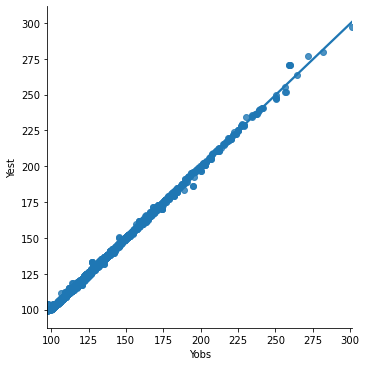

In [23]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [24]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
rf_mape = mape(y_test,yest_test)

r2,rmse,rrmse,rf_mape

(0.9989802243168775,
 0.6995520808358664,
 0.5353119417043101,
 0.25607515272572506)

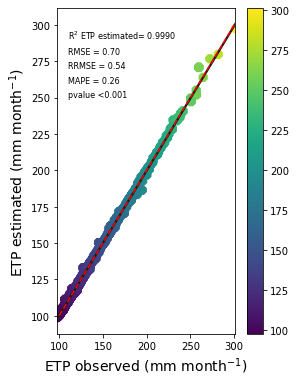

In [25]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")  #cmap é a cor da barra  
cbar = plt.colorbar(points, shrink=1)
#cbar.set_label('XCO$\mathregular{_{2}}$ estimated',fontsize=14, family='Segoe UI Bold')  #COLOCAR O NOME DA BARRA
sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[100,300]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(110, 290, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(110,280, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,270, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,260, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(110, 250,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('random_forest_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **StepWise** 

In [26]:
# checando
x_train.head(), y_train.head()

(         lon   lat  year  month   (prec,)   (temp,)
 14083 -60.25 -1.25  1998      8 -1.113714  0.070567
 13017 -60.25 -2.00  2011     10 -0.235018  0.556544
 11578 -60.25 -2.75  1993     11 -0.334300 -0.460488
 3292  -61.00 -2.50  1983      5 -0.398281  0.180547
 13968 -60.25 -1.25  1989      1  0.452536 -1.525543,
 14083    132.035181
 13017    142.787187
 11578    121.857273
 3292     133.351498
 13968    106.459225
 Name: etp, dtype: float64)

## **Train**

In [27]:
sw_model = LinearRegression()
sfs_model = sfs(sw_model,k_features=6, forward=True, scoring='r2',cv=10)
sfs_model=sfs_model.fit(x_train, y_train)
sfs_model.k_feature_names_

('lon', 'lat', 'year', 'month', ('prec',), ('temp',))

In [28]:
table = pd.DataFrame.from_dict(sfs_model.get_metric_dict()).T
table

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(5,)","[0.9376195398722683, 0.9488572368918473, 0.951...",0.943686,"((temp,),)",0.0045,0.006059,0.00202
2,"(3, 5)","[0.9442842062652023, 0.9534283496450455, 0.955...",0.94851,"(month, (temp,))",0.004261,0.005737,0.001912
3,"(0, 3, 5)","[0.9445500692048696, 0.9545563455428883, 0.956...",0.949672,"(lon, month, (temp,))",0.00414,0.005574,0.001858
4,"(0, 2, 3, 5)","[0.9452528009196245, 0.9554736980660826, 0.957...",0.950409,"(lon, year, month, (temp,))",0.004087,0.005503,0.001834
5,"(0, 1, 2, 3, 5)","[0.9460136080886363, 0.9557621545578019, 0.958...",0.951182,"(lon, lat, year, month, (temp,))",0.003988,0.00537,0.00179
6,"(0, 1, 2, 3, 4, 5)","[0.9463671287782878, 0.9560402456344015, 0.958...",0.951485,"(lon, lat, year, month, (prec,), (temp,))",0.003885,0.005231,0.001744


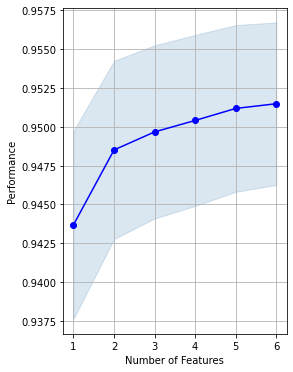

In [29]:
figure = plot_sfs(sfs_model.get_metric_dict(),kind='std_dev')
plt.grid()

In [30]:
table=table.sort_values('avg_score', ascending=False)['feature_names'].head(1)
table = table.tolist()
        
xobs_train = x_train[list(table[0][0:])]

xobs_train = sm.add_constant(xobs_train)
xobs_train.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


,const,lon,lat,year,month,"(prec,)","(temp,)"
14083,1.0,-60.25,-1.25,1998,8,-1.113714,0.070567
13017,1.0,-60.25,-2.00,2011,10,-0.235018,0.556544
11578,1.0,-60.25,-2.75,1993,11,-0.334300,-0.460488
3292,1.0,-61.00,-2.50,1983,5,-0.398281,0.180547
13968,1.0,-60.25,-1.25,1989,1,0.452536,-1.525543


In [31]:
result = sm.OLS(y_train,xobs_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    etp   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 3.961e+04
Date:                Wed, 14 Feb 2024   Prob (F-statistic):               0.00
Time:                        15:16:35   Log-Likelihood:                -34893.
No. Observations:               11995   AIC:                         6.980e+04
Df Residuals:                   11988   BIC:                         6.985e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        350.0380     10.527     33.250      0.000     329.403     370.673
lon            1.7518      0.096     18.266      0.000       1.564       1.940
lat            1.1927      0.082     14.512      0.000       1.032       1.354
year          -0.0572      0.004    -13.265      0.000      -0.066      -0.049
month          0.4372      0.013     32.538      0.000       0.411       0.464
('prec',)      0.4312      0.049      8.714      0.000       0.334       0.528
('temp',)     20.0302      0.050    400.305      0.000      19.932      20.128
==============================================================================
Omnibus:                     5081.084   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           117352.325
Skew:                           1.500   Prob(JB):                         0.00
Kurtosis:                      18.027   Cond. No.                     5.19e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.19e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
yest_train=result.fittedvalues
pd.DataFrame.from_dict(yest_train).to_csv('sw_train_est.csv')

In [33]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
14083,132.035181,133.117093
13017,142.787187,142.466264
11578,121.857273,122.624653
3292,133.351498,132.370359
13968,106.459225,99.276526


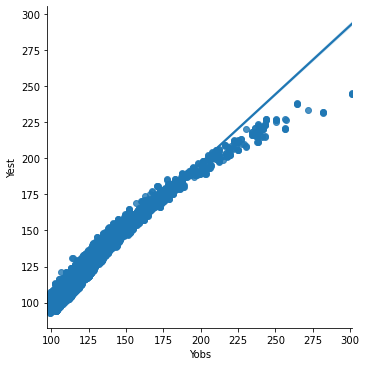

In [34]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [35]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train, yest_train)
rrmse = rmse*100/np.mean(y_train)
sw_mape = mape(y_train,yest_train)

r2,rmse,rrmse,sw_mape

(0.9519821181957625,
 4.4372900374633515,
 3.4204272141162937,
 2.4498399379201015)

## **Test**

In [36]:
xobs_test = x_test[list(table[0][0:])]
xobs_test = sm.add_constant(xobs_test)
yest_test = result.predict(xobs_test)

pd.DataFrame.from_dict(yest_test).to_csv('sw_test_est.csv')
yest_test.head()

C:\Users\luism\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


9146     133.850531
5024     130.405048
10854    108.197006
1246     134.250663
7883     170.257942
dtype: float64

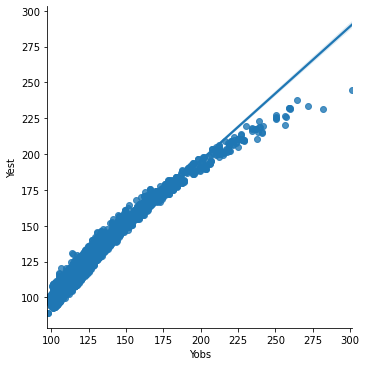

In [37]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [38]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
sw_mape = mape(y_test,yest_test)

r2,rmse,rrmse,sw_mape

(0.9556569056039722, 4.6129710059237405, 3.529942278573687, 2.4951163432726853)

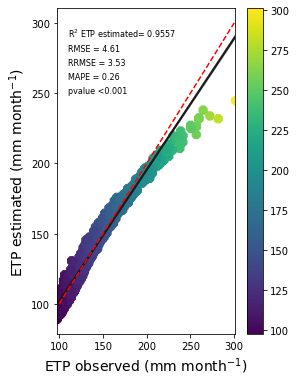

In [39]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")    
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[100,300]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(110, 290, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(110,280, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,270, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,260, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(110, 250,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('sw_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **MLP**

In [40]:
# checando 

x_train.head(),y_train.head()

(         lon   lat  year  month   (prec,)   (temp,)
 14083 -60.25 -1.25  1998      8 -1.113714  0.070567
 13017 -60.25 -2.00  2011     10 -0.235018  0.556544
 11578 -60.25 -2.75  1993     11 -0.334300 -0.460488
 3292  -61.00 -2.50  1983      5 -0.398281  0.180547
 13968 -60.25 -1.25  1989      1  0.452536 -1.525543,
 14083    132.035181
 13017    142.787187
 11578    121.857273
 3292     133.351498
 13968    106.459225
 Name: etp, dtype: float64)

In [41]:
mlp_model= MLPRegressor().fit(x_train,y_train)

## **Random Search param**

In [42]:
max_iter = [int(x) for x in np.linspace(start = 50, stop = 2050, num = 100)]
# Maximum number of levels in tree
alpha = [float(x) for x in np.arange(0.001, .3, 0.001)]
learning_rate_init = alpha


hyperpar_space_mlp = {'hidden_layer_sizes':[(5,5),(10,10),(10,5,10),(10,10,10),
                                           (50,10,50),(50,10,5),(5,10,100)],
                          'activation':['logistic','tanh','identity'],
                          'max_iter':max_iter,
                          'learning_rate_init': learning_rate_init,
                          'solver':['adam','sgd','lbfgs'],
                          'learning_rate':['constant', 'invscaling', 'adaptive'],
                          'alpha':alpha
                         }

In [43]:
rs_mlp = RandomizedSearchCV(mlp_model, param_distributions=hyperpar_space_mlp,
                        n_iter=20, scoring="r2", random_state=1,
                        n_jobs=-1, cv=10, return_train_score=True).fit(x_train,y_train)

C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: [-2.52601986e+01 -1.50941128e-03 -1.51166712e-03  9.47059688e-01
 -1.51021116e-03 -1.35052581e-03  2.50465491e-01             nan
  9.46090657e-01             nan -5.85241740e-02 -2.79207947e-03
  9.45544660e-01  8.06062995e-01 -1.73457715e-03 -1.51124983e-03
 -1.88568377e-03  9.37588238e-01  1.82627057e-01 -1.51131615e-03]
  warnings.warn(
C:\Users\luism\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the train scores are non-finite: [-2.31528428e+01 -7.34860213e-09 -1.24271159e-07  9.47554816e-01
  9.68960103e-07 -1.80348178e-05  2.47744452e-01             nan
  9.46784474e-01             nan -6.05293805e-02 -8.88217328e-04
  9.45803014e-01  8.21731789e-01 -8.52717159e-05 -4.64881023e-11
 -9.30150806e-05  9.38157185e-01  1.83648510e-01 -4.24675961e-11]
  warnings.warn(


In [44]:
print("Optimal hyperparameter combination:", rs_mlp.best_params_)
print()
print("Mean cross-validated training accuracy score:",
      rs_mlp.best_score_)

Optimal hyperparameter combination: {'solver': 'lbfgs', 'max_iter': 1322, 'learning_rate_init': 0.038, 'learning_rate': 'invscaling', 'hidden_layer_sizes': (10, 5, 10), 'alpha': 0.092, 'activation': 'identity'}

Mean cross-validated training accuracy score: 0.9470596881451453


In [45]:
pd.DataFrame.from_dict(rs_mlp.cv_results_).to_csv('mlp_iter.csv')
pd.DataFrame.from_dict(rs_mlp.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_learning_rate,param_hidden_layer_sizes,param_alpha,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,32.726584,0.868924,0.005004,0.002096,sgd,555,0.138,invscaling,"(10, 5, 10)",0.204,...,-2.426916e-05,-2.823108e-05,-1.251511e+02,-3.121598e-05,-5.056902e-05,-1.252214e-05,-4.277141e-05,-2.061648e-06,-2.315284e+01,4.649554e+01
1,7.861580,0.953396,0.005231,0.004732,sgd,1140,0.143,adaptive,"(10, 10)",0.001,...,-2.279219e-08,-1.061469e-08,-6.560489e-09,-9.672871e-10,-3.468338e-09,-1.087180e-08,-6.958906e-09,-6.162711e-09,-7.348602e-09,6.088003e-09
2,6.181281,0.238492,0.003054,0.001366,sgd,130,0.236,adaptive,"(5, 5)",0.293,...,-4.936582e-07,-1.694369e-10,-1.033411e-07,-4.145982e-08,-1.175526e-07,-2.909075e-07,-6.612545e-08,-2.205203e-08,-1.242712e-07,1.452200e-07
3,4.885054,2.032217,0.005567,0.004445,lbfgs,1322,0.038,invscaling,"(10, 5, 10)",0.092,...,9.468717e-01,9.483361e-01,9.476766e-01,9.470188e-01,9.473865e-01,9.470196e-01,9.483059e-01,9.485085e-01,9.475548e-01,6.048085e-04
4,0.993881,0.545650,0.009995,0.001265,lbfgs,433,0.266,constant,"(50, 10, 50)",0.036,...,-2.453593e-12,-3.243183e-12,-3.818057e-12,-4.440004e-12,-2.060352e-12,-1.546763e-12,-1.692868e-12,-2.370326e-12,9.689601e-07,2.906887e-06
5,2.036983,0.566096,0.005501,0.004232,adam,938,0.086,constant,"(10, 5, 10)",0.24,...,-1.157363e-06,-4.248498e-05,-1.241481e-05,-6.917992e-07,-1.233970e-07,-2.383065e-05,-4.922839e-08,-4.385037e-05,-1.803482e-05,1.994087e-05
6,13.002212,19.603993,0.005808,0.004208,lbfgs,1706,0.092,adaptive,"(10, 10, 10)",0.211,...,2.931389e-01,-2.420661e-10,1.730404e-06,9.300268e-01,1.175570e-06,2.964608e-01,9.567307e-01,1.084361e-03,2.477445e-01,3.661053e-01
7,15.406860,0.326101,0.024872,0.012102,sgd,151,0.124,adaptive,"(50, 10, 50)",0.126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8.131942,3.439661,0.004991,0.003583,lbfgs,999,0.22,constant,"(10, 10, 10)",0.287,...,9.468302e-01,9.483940e-01,9.478310e-01,9.469965e-01,9.473181e-01,9.469296e-01,9.481604e-01,9.483879e-01,9.467845e-01,2.374527e-03
9,9.904036,0.287392,0.011771,0.003963,sgd,130,0.286,constant,"(5, 10, 100)",0.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(-1.0, 1.0)

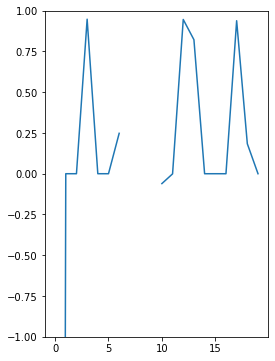

In [46]:
pd.DataFrame.from_dict(rs_mlp.cv_results_)['mean_train_score'].plot()
plt.ylim(-1,1)

## **Train**

In [47]:
yest_train = rs_mlp.best_estimator_.predict(x_train)
pd.DataFrame.from_dict(yest_train).to_csv('mlp_train_est.csv')

In [48]:
datagraf = pd.DataFrame({'Yobs':y_train,
                         'Yest': yest_train})
datagraf.head()

,Yobs,Yest
14083,132.035181,132.365523
13017,142.787187,143.684801
11578,121.857273,122.111026
3292,133.351498,130.861695
13968,106.459225,97.804798


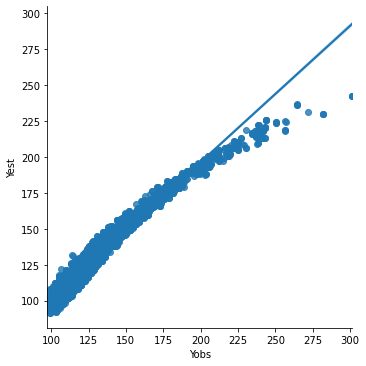

In [49]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [50]:
r2 = skm.r2_score(y_train,yest_train)
mse=skm.mean_squared_error(y_train,yest_train)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_train,yest_train)
rrmse = rmse*100/np.mean(y_train)
ann_mape = mape(y_train,yest_train)

r2,rmse,rrmse,ann_mape

(0.9474561338674411, 4.641702799991412, 3.577996128918033, 2.5732137464081917)

## **Test**

In [51]:
x_test.head(),y_test.head()

(         lon  lat  year  month   (prec,)   (temp,)
 9146  -60.50 -2.5  1995      3  1.595884  0.245720
 5024  -61.00 -1.5  1991      9 -0.987355 -0.028895
 10854 -60.50 -1.5  2001      7 -0.492750 -1.119779
 1246  -61.25 -2.0  1982     11 -0.908732  0.143678
 7883  -60.75 -1.5  1991     12 -1.369340  1.881623,
 9146     135.307742
 5024     126.065963
 10854    112.639454
 1246     130.479992
 7883     170.918518
 Name: etp, dtype: float64)

In [52]:
yest_test = rs_mlp.best_estimator_.predict(x_test)
pd.DataFrame.from_dict(yest_test).to_csv('mlp_test_est.csv')


In [53]:
datagraf = pd.DataFrame({'Yobs':y_test,
                         'Yest': yest_test})
datagraf.head()

,Yobs,Yest
9146,135.307742,133.407794
5024,126.065963,129.942802
10854,112.639454,108.771834
1246,130.479992,133.131053
7883,170.918518,168.794718


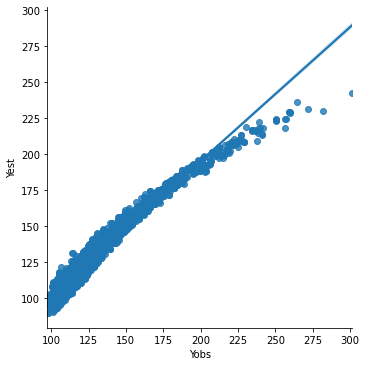

In [54]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [55]:
r2 = skm.r2_score(y_test,yest_test)
mse=skm.mean_squared_error(y_test,yest_test)
rmse = mse**0.5
rrmse = rmse*100/np.mean(y_test)
ann_mape = mape(y_test,yest_test)

r2,rmse,rrmse,ann_mape

(0.9513288667318123, 4.832851560159996, 3.698199495807019, 2.6161461315108494)

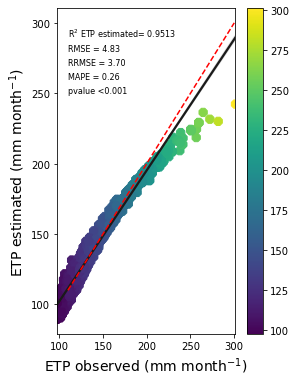

In [56]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")  
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[110,300]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(110, 290, 'R$\mathregular{^{2}}$ ETP estimated= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(110,280, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,270, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,260, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(110, 250,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP estimated (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('ann_teste.png', transparent = False,bbox_inches='tight', dpi=1000)

# **General forecasting**

In [57]:
yest_validation = rs_rf.best_estimator_.predict(x_validation)

In [58]:
datagraf = pd.DataFrame({'Yobs':y_validation,
                         'Yest': yest_validation})
datagraf.head()

,Yobs,Yest
0,113.772924,114.797230
1,113.266134,113.194357
2,119.822282,119.377808
3,118.194390,118.820143
4,121.540763,120.170654


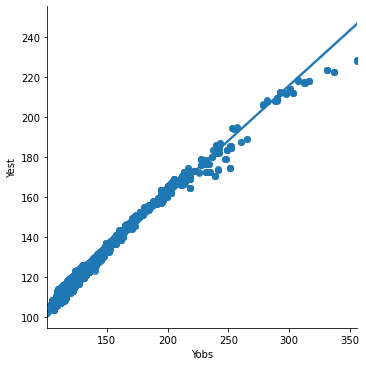

In [59]:
sns.lmplot(x='Yobs',y='Yest',data=datagraf);

In [60]:
r2 = skm.r2_score(y_validation,yest_validation)
mse=skm.mean_squared_error(y_validation,yest_validation)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_validation, yest_validation)
rrmse = rmse*100/np.mean(y_validation)
rf_mape = mape(y_validation,yest_validation)



r2,rmse,rrmse, rf_mape

(0.6467884416074581, 21.454455514737113, 14.965485156845993, 8.296127339983252)

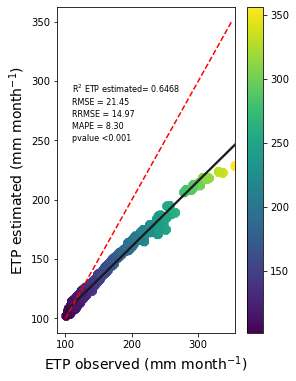

In [61]:
points = plt.scatter(y='Yest', x='Yobs',data=datagraf,
                     c=datagraf["Yobs"],marker="8", s=80, cmap="viridis")   
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=datagraf, scatter=False, color=".1")

x=[100,350]
y=x

plt.plot(x,y, '--',color='red',data=None)

pvalue = 0.001
plt.text(110, 290, 'R$\mathregular{^{2}}$ ETP forecasted= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(110,280, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,270, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(110,260, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(110, 250,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP forecasted (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('rf_validation.png', transparent = False,bbox_inches='tight', dpi=1000)

In [62]:
prec = data_validation['prec']
datagraf['prec']=prec
datagraf['et_obs']=datagraf['Yobs']
datagraf['et_est']=datagraf['Yest']
datagraf['year']=data_validation['year']
datagraf['month']=data_validation['month']

datagraf.to_csv('est_validiation.csv')

# **Time series forecasting**

In [63]:
df15 = x_validation[(x_validation['year']==2015)]
df16= x_validation[(x_validation['year']==2016)]
df17= x_validation[(x_validation['year']==2017)]
df18= x_validation[(x_validation['year']==2018)]
df19= x_validation[(x_validation['year']==2019)]
df20= x_validation[(x_validation['year']==2020)]
df21= x_validation[(x_validation['year']==2021)]


In [64]:
y_15=y_validation[y_validation.index.isin(df15.index)]
y_16=y_validation[y_validation.index.isin(df16.index)]
y_17=y_validation[y_validation.index.isin(df17.index)]
y_18=y_validation[y_validation.index.isin(df18.index)]
y_19=y_validation[y_validation.index.isin(df19.index)]
y_20=y_validation[y_validation.index.isin(df20.index)]
y_21=y_validation[y_validation.index.isin(df21.index)]

In [65]:
yest_15 =rs_rf.best_estimator_.predict(df15)
datagraf = pd.DataFrame({'Yobs':y_15,
                         'Yest': yest_15})
r2 = skm.r2_score(y_15,yest_15)
mse=skm.mean_squared_error(y_15,yest_15)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_15, yest_15)
rrmse = rmse*100/np.mean(y_15)
rf_mape = mape(y_15,yest_15)



r2,rmse,rrmse, rf_mape

(0.6360995212299827, 41.62734418700019, 24.404085818690863, 10.865215135947704)

In [66]:
yest_16 =rs_rf.best_estimator_.predict(df16)
datagraf = pd.DataFrame({'Yobs':y_16,
                         'Yest': yest_16})
r2 = skm.r2_score(y_16,yest_16)
mse=skm.mean_squared_error(y_16,yest_16)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_16, yest_16)
rrmse = rmse*100/np.mean(y_16)
rf_mape = mape(y_16,yest_16)



r2,rmse,rrmse, rf_mape

(0.462693541008929, 27.7198121518475, 17.218816747835493, 11.275490633546893)

In [67]:
yest_17 =rs_rf.best_estimator_.predict(df17)
datagraf = pd.DataFrame({'Yobs':y_17,
                         'Yest': yest_17})
r2 = skm.r2_score(y_17,yest_17)
mse=skm.mean_squared_error(y_17,yest_17)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_17, yest_17)
rrmse = rmse*100/np.mean(y_17)
rf_mape = mape(y_17,yest_17)



r2,rmse,rrmse, rf_mape

(0.6178904047923686, 16.393167962704887, 11.559307674600188, 8.109431339658453)

In [68]:
yest_18 =rs_rf.best_estimator_.predict(df18)
datagraf = pd.DataFrame({'Yobs':y_18,
                         'Yest': yest_18})
r2 = skm.r2_score(y_18,yest_18)
mse=skm.mean_squared_error(y_18,yest_18)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_18, yest_18)
rrmse = rmse*100/np.mean(y_18)
rf_mape = mape(y_18,yest_18)



r2,rmse,rrmse, rf_mape

(0.6177688506666967, 11.543430814698171, 8.710891992639157, 6.5194355599905665)

In [69]:
yest_19 =rs_rf.best_estimator_.predict(df19)

datagraf = pd.DataFrame({'Yobs':y_19,
                         'Yest': yest_19})
r2 = skm.r2_score(y_19,yest_19)
mse=skm.mean_squared_error(y_19,yest_19)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_19, yest_19)
rrmse = rmse*100/np.mean(y_19)
rf_mape = mape(y_19,yest_19)



r2,rmse,rrmse, rf_mape


(-0.22802017381969408,
 10.184655195436292,
 7.670510098192959,
 7.219564809650618)

In [70]:
yest_20 =rs_rf.best_estimator_.predict(df20)

datagraf = pd.DataFrame({'Yobs':y_20,
                         'Yest': yest_20})
r2 = skm.r2_score(y_20,yest_20)
mse=skm.mean_squared_error(y_20,yest_20)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_20, yest_20)
rrmse = rmse*100/np.mean(y_20)
rf_mape = mape(y_20,yest_20)



r2,rmse,rrmse, rf_mape

(0.18083925269259826, 11.469845964954393, 8.430034546542894, 7.530231560459083)

In [71]:
yest_21 =rs_rf.best_estimator_.predict(df21)
datagraf = pd.DataFrame({'Yobs':y_21,
                         'Yest': yest_21})
r2 = skm.r2_score(y_21,yest_21)
mse=skm.mean_squared_error(y_21,yest_21)
rmse = mse**0.5
mae = skm.mean_absolute_error(y_21, yest_21)
rrmse = rmse*100/np.mean(y_21)
rf_mape = mape(y_21,yest_21)



r2,rmse,rrmse, rf_mape

(0.008349004563337425, 9.141145524673597, 7.097992530690666, 6.55352234062956)

# **stat**

In [72]:
from scipy import stats
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [73]:
data = pd.read_csv('tab_training.csv')
data[['etp']].describe().T

,count,mean,std,min,25%,50%,75%,max
etp,17136.0,130.014754,20.765681,97.433443,117.192072,125.408361,136.662145,301.533293


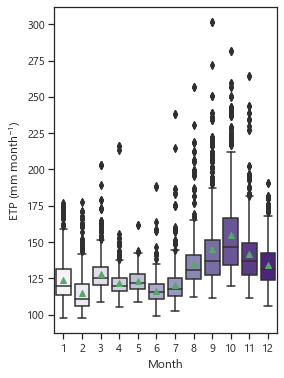

In [74]:
x = data[['etp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Purples',data=x, x= 'month',y='etp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('ETP (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('etpanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [75]:
data[['prec']].describe().T

,count,mean,std,min,25%,50%,75%,max
prec,17136.0,194.434982,99.718804,9.22,116.66,177.34,264.47,722.68


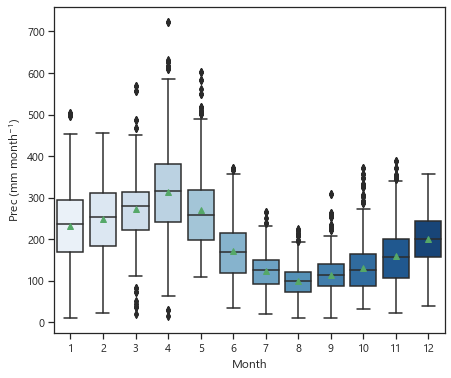

In [76]:
x = data[['prec','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Blues',data=x, x= 'month',y='prec' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Prec (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('prec.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [77]:
data[['temp']].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,17136.0,26.065414,1.029549,23.995806,25.38069,25.856333,26.519402,31.884


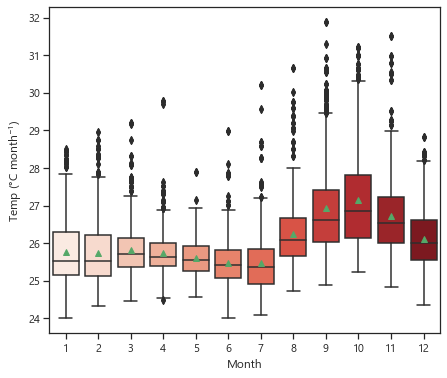

In [78]:
x = data[['temp','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='Reds',data=x, x= 'month',y='temp' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('Temp (°C month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('temp.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()

In [79]:
data.groupby('month')[['etp']].describe()

etp                                                             \
        count        mean        std         min         25%         50%   
month                                                                      
1      1428.0  124.193289  15.481261   97.611363  113.340748  119.520656   
2      1428.0  115.187557  13.114099   97.433443  106.084597  111.084550   
3      1428.0  128.210833  12.154432  109.098317  120.317659  125.629853   
4      1428.0  121.714361   9.631711  105.389036  116.487896  119.857604   
5      1428.0  123.025077   7.255217  108.584517  117.701197  121.775700   
6      1428.0  116.468932   9.187033   99.106398  110.715777  115.680568   
7      1428.0  120.551075  13.745465  102.574340  112.671785  117.804149   
8      1428.0  134.981815  17.066999  112.281870  124.600864  130.886518   
9      1428.0  144.934415  26.689819  111.344464  127.235138  136.960787   
10     1428.0  155.176139  29.261994  119.628516  133.981806  146.313561   
11     1428.0  141.634341  21.358922  111.287450  127.381694  136.791946   
12     1428.0  134.099213  14.234911  106.294468  124.194955  131.532236   

                               
              75%         max  
month                          
1      131.747127  176.957269  
2      121.173107  177.787602  
3      132.831707  203.414895  
4      125.138500  215.874188  
5      127.754019  161.929407  
6      121.058280  188.381161  
7      125.417212  238.158773  
8      141.152587  256.798171  
9      151.413784  301.533293  
10     166.343012  281.722061  
11     149.130002  264.456180  
12     142.274767  190.581123

In [80]:
data.groupby('month')[['prec']].describe()

prec                                                                
        count        mean        std     min     25%      50%     75%     max
month                                                                        
1      1428.0  231.206723  95.070364   10.86  170.20  237.275  293.12  503.96
2      1428.0  247.936148  85.542013   23.12  182.59  253.820  310.73  456.04
3      1428.0  271.864076  75.957935   19.38  222.04  280.610  313.80  569.73
4      1428.0  313.939188  99.459208   14.58  242.12  316.155  380.15  722.68
5      1428.0  269.162857  89.671145  108.73  199.17  257.710  317.75  602.16
6      1428.0  172.629412  69.039222   33.82  117.56  168.160  215.62  371.12
7      1428.0  123.336681  42.996878   20.07   92.74  125.440  149.61  266.31
8      1428.0   98.602465  41.178460    9.22   72.32   99.950  121.89  224.11
9      1428.0  113.689692  47.030133    9.60   86.21  114.975  140.43  308.06
10     1428.0  131.336387  57.272305   32.56   87.38  126.570  163.26  371.25
11     1428.0  158.914174  70.851427   22.19  105.68  156.865  199.79  387.11
12     1428.0  200.601989  62.380237   38.74  157.26  199.955  243.61  357.50

In [81]:
data.groupby('month')[['temp']].describe()

temp                                                        \
        count       mean       std        min        25%        50%   
month                                                                 
1      1428.0  25.767882  0.902866  23.995806  25.145484  25.527419   
2      1428.0  25.745842  0.820147  24.327931  25.136552  25.524286   
3      1428.0  25.825204  0.682645  24.460323  25.368387  25.700645   
4      1428.0  25.732345  0.556381  24.479333  25.392333  25.637000   
5      1428.0  25.615355  0.486683  24.568710  25.252581  25.560000   
6      1428.0  25.469524  0.599602  24.019333  25.072667  25.430500   
7      1428.0  25.459948  0.783071  24.085484  24.915806  25.372903   
8      1428.0  26.246076  0.851426  24.714194  25.668710  26.083548   
9      1428.0  26.926340  1.218714  24.875333  26.031000  26.615833   
10     1428.0  27.153695  1.288817  25.232903  26.149677  26.861613   
11     1428.0  26.732535  1.044495  24.826667  25.994333  26.547833   
12     1428.0  26.110224  0.775449  24.350968  25.545484  25.998710   

                             
             75%        max  
month                        
1      26.291290  28.505484  
2      26.208571  28.965357  
3      26.144516  29.190645  
4      25.991333  29.770667  
5      25.936452  27.902581  
6      25.812333  28.986667  
7      25.837742  30.209355  
8      26.679032  30.667742  
9      27.404667  31.884000  
10     27.817419  31.210645  
11     27.232667  31.511000  
12     26.613871  28.826774

In [82]:
data = pd.read_csv('climatology.csv')
data

,Unnamed: 0,station,month,prec,temp,etp,etr,def,exc,wb
0,1,-61.25_-2.75,1,255.209706,25.777751,123.783665,123.783665,0.000000,131.426040,131.426040
1,2,-61.25_-2.75,2,261.882353,25.708462,114.062010,114.062010,0.000000,147.820343,147.820343
2,3,-61.25_-2.75,3,287.630588,25.800731,127.264697,127.264697,0.000000,160.365892,160.365892
3,4,-61.25_-2.75,4,310.264412,25.701990,120.679259,120.679259,0.000000,189.585153,189.585153
4,5,-61.25_-2.75,5,258.937353,25.636129,122.813572,122.813572,0.000000,136.123781,136.123781
...,...,...,...,...,...,...,...,...,...,...
499,500,-60_-1.25,8,105.755588,25.649478,124.654361,122.975922,1.678439,0.000000,-1.678439
500,501,-60_-1.25,9,111.773824,26.341343,132.553386,127.305520,5.247866,0.000000,-5.247866
501,502,-60_-1.25,10,126.274118,26.567258,141.469596,135.754257,5.715338,0.000000,-5.715338
502,503,-60_-1.25,11,139.794706,26.288912,132.401019,132.401019,0.000000,0.000000,0.000000


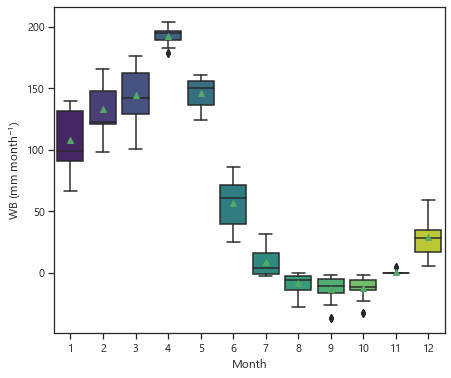

In [83]:
x = data[['wb','month']]
sns.set(style="ticks",font='Segoe UI', color_codes= True)
sns.boxplot(palette='viridis',data=x, x= 'month',y='wb' ,showmeans=True)
plt.rcParams['figure.figsize'] = (7,6)  #largura x altura
plt.xlabel('Month',fontsize=12, family='Segoe UI')
plt.ylabel('WB (mm month$\mathregular{^{-1}}$)',fontsize=12, family='Segoe UI')
#plt.legend(['means'],loc=)
plt.savefig('wdanos.png', transparent = False,bbox_inches='tight', dpi=1000)
plt.show()